# Model Evaluation and Diagnostics

After building and refining regression models, it is essential to evaluate their performance and validate underlying assumptions.

A well-performing model is not only accurate but also statistically reliable.

This notebook focuses on:

- Evaluating model performance using appropriate metrics
- Comparing multiple models
- Performing regression diagnostics
- Validating model assumptions

These steps ensure that the model is both accurate and robust for real-world application.

## Import Required Libraries

We use:

- `dplyr`: data manipulation  
- `ggplot2`: visualization  
- `caret`: performance metrics  
- `car`: diagnostic tools for regression  

In [1]:
# Load required libraries

# dplyr for data manipulation
library(dplyr)

# ggplot2 for visualization
library(ggplot2)

# caret for model evaluation
library(caret)

# car package for regression diagnostics (e.g., VIF)
library(car)

# Import the readr package which is used for reading the csv files
library(readr) 


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: lattice
Loading required package: carData

Attaching package: 'car'

The following object is masked from 'package:dplyr':

    recode



## Load Dataset and Models

We load the dataset and recreate the refined model for evaluation purposes.

In [2]:
# Load dataset
bike_data <- read_csv("clean_bike_data.csv")

# Split data
set.seed(123)
train_index <- createDataPartition(bike_data$rented_bike_count, p = 0.8, list = FALSE)

train_data <- bike_data[train_index, ]
test_data <- bike_data[-train_index, ]

# Add polynomial and interaction features
train_data <- train_data %>%
  mutate(
    temperature_sq = temperature^2,
    humidity_sq = humidity^2,
    temp_humidity = temperature * humidity
  )

test_data <- test_data %>%
  mutate(
    temperature_sq = temperature^2,
    humidity_sq = humidity^2,
    temp_humidity = temperature * humidity
  )

# Train refined model
model <- lm(
  rented_bike_count ~ temperature + humidity + wind_speed +
    temperature_sq + humidity_sq + temp_humidity,
  data = train_data
)

Rows: 8465 Columns: 17── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (4): seasons, holiday, functioning_day, day_of_week
dbl  (12): rented_bike_count, hour, temperature, humidity, wind_speed, visib...
date  (1): date
ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

## Model Performance Metrics

We evaluate model performance using:

- RMSE (Root Mean Squared Error)
- R-squared (Coefficient of Determination)

In [3]:
# Generate predictions
predictions <- predict(model, newdata = test_data)

# RMSE function
rmse <- function(actual, predicted) {
  sqrt(mean((actual - predicted)^2))
}

# Calculate RMSE
rmse_value <- rmse(test_data$rented_bike_count, predictions)

# Calculate R-squared
r2_value <- cor(test_data$rented_bike_count, predictions)^2

# Display results
rmse_value
r2_value

[1] 472.472

[1] 0.4568859

## Residual Analysis

Residuals represent the difference between actual and predicted values.

Analyzing residuals helps identify:

- Model bias
- Non-linearity
- Heteroscedasticity

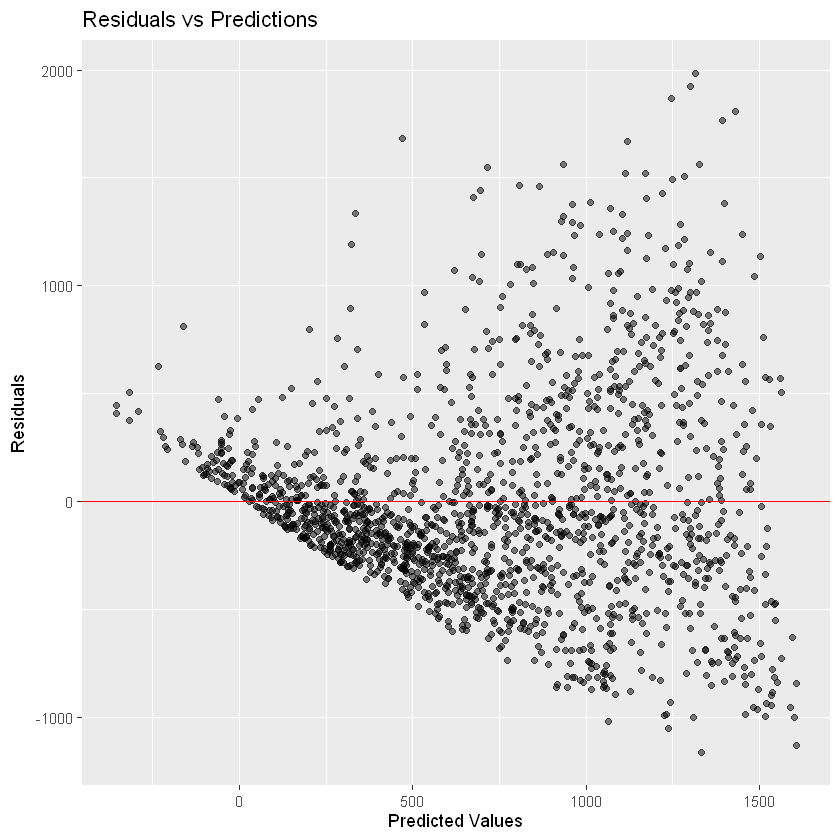

In [4]:
# Calculate residuals
residuals <- test_data$rented_bike_count - predictions

# Residual plot

ggplot(data.frame(predictions, residuals), aes(x = predictions, y = residuals)) +
  geom_point(alpha = 0.5) +
  geom_hline(yintercept = 0, color = "red") +
  labs(
    title = "Residuals vs Predictions",
    x = "Predicted Values",
    y = "Residuals"
  )

## Q-Q Plot (Normality Check)

A Q-Q plot is used to assess whether residuals follow a normal distribution.

Normality of residuals is an important assumption in linear regression.

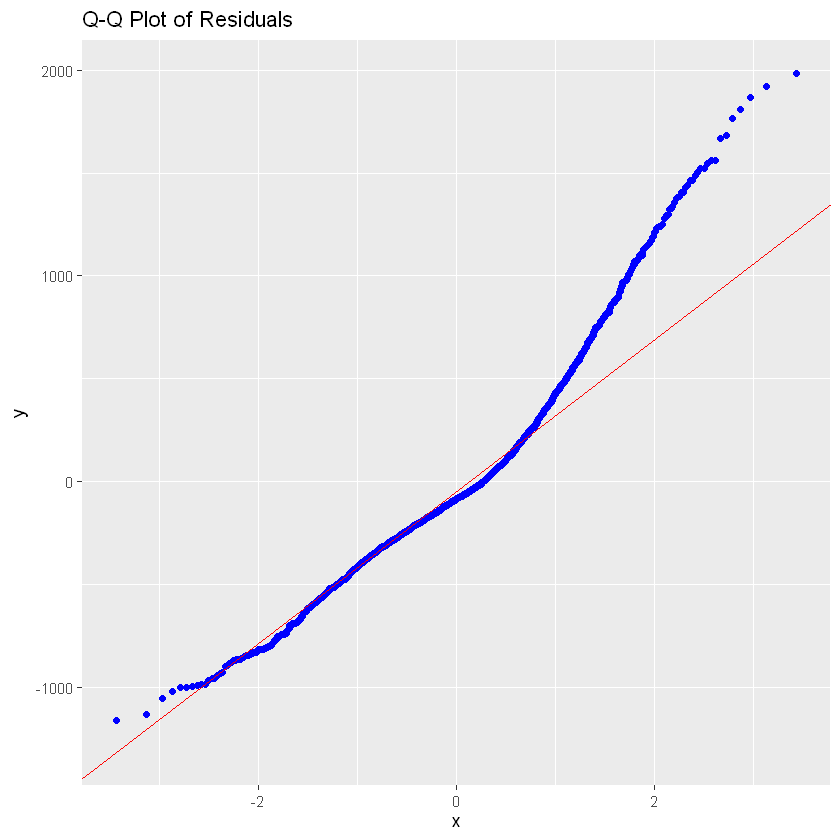

In [5]:
# Q-Q plot for residuals

ggplot(data.frame(residuals), aes(sample = residuals)) +
  stat_qq(color = "blue") +
  stat_qq_line(color = "red") +
  labs(title = "Q-Q Plot of Residuals")

## Homoscedasticity Check

Homoscedasticity means that residuals have constant variance.

If variance increases or decreases with predictions, it indicates heteroscedasticity.

`geom_smooth()` using formula = 'y ~ x'

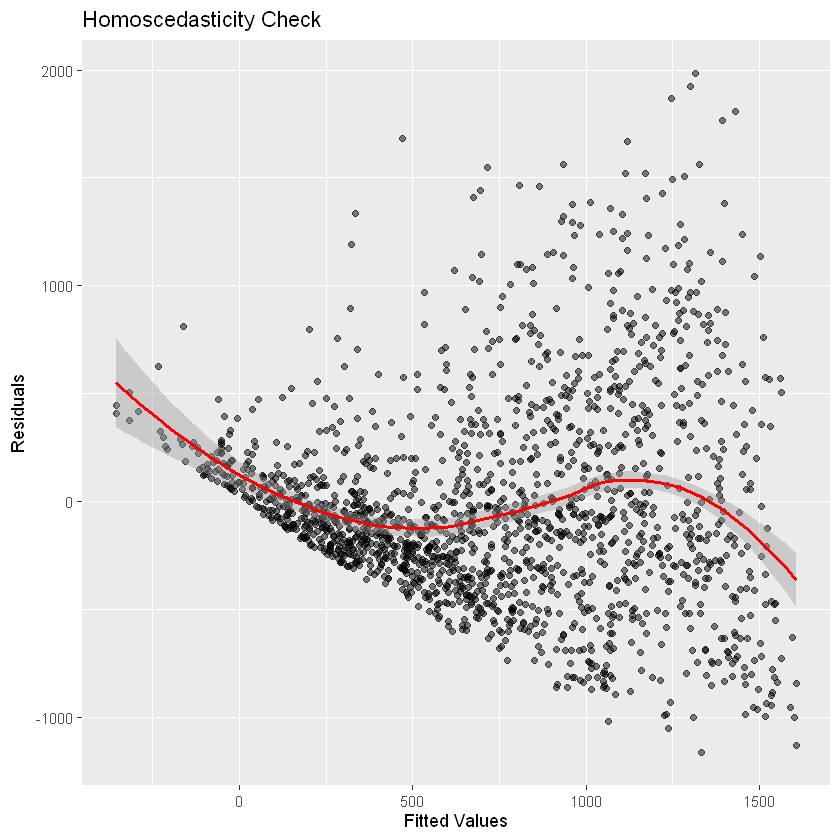

In [6]:
# Plot residuals vs fitted values

ggplot(data.frame(fitted = predictions, residuals = residuals),
       aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "loess", color = "red") +
  labs(
    title = "Homoscedasticity Check",
    x = "Fitted Values",
    y = "Residuals"
  )

## Multicollinearity Check (VIF)

Multicollinearity occurs when predictors are highly correlated.

We use Variance Inflation Factor (VIF):

- VIF > 5 or 10 indicates potential issues

In [7]:
# Calculate VIF for model predictors

vif_values <- vif(model)

# Display VIF values
vif_values

temperature       humidity     wind_speed temperature_sq    humidity_sq 
     12.033735      29.828846       1.149104       4.913086      30.561802 
 temp_humidity 
     13.068626

## Model Comparison (Optional)

We can compare baseline and refined models to assess improvement.

In [8]:
# Train baseline model for comparison

baseline_model <- lm(
  rented_bike_count ~ temperature + humidity + wind_speed,
  data = train_data
)

# Predictions for baseline
baseline_pred <- predict(baseline_model, newdata = test_data)

# RMSE comparison
rmse_baseline <- rmse(test_data$rented_bike_count, baseline_pred)
rmse_refined <- rmse(test_data$rented_bike_count, predictions)

rmse_baseline
rmse_refined

[1] 491.4609

[1] 472.472

## Interpretation

The evaluation results indicate that the refined model achieves improved predictive performance compared to the baseline, as reflected by a lower RMSE value. This suggests that the inclusion of engineered features and regularization techniques has enhanced the model’s ability to generalize.

Analysis of residual plots shows that the residuals are reasonably centered around zero, indicating that the model does not exhibit strong systematic bias. However, slight dispersion patterns may still exist, reflecting the inherent variability in real-world demand data.

The Q-Q plot demonstrates that the residuals approximately follow a normal distribution, although minor deviations at the tails suggest the presence of outliers or non-linear effects not fully captured by the model.

Variance Inflation Factor (VIF) analysis highlights the presence of multicollinearity among engineered features such as polynomial and interaction terms. While this is expected due to feature construction, the use of regularization techniques (Ridge, Lasso, Elastic Net) helps mitigate its impact by controlling coefficient magnitude.

Overall, the diagnostic checks confirm that the refined model is statistically stable, with acceptable assumptions for linear modeling and improved predictive reliability compared to the baseline.

---

## Author & Acknowledgment

**Author:**  
<span style="color:blue">Deepan Mehta </span>  

**GitHub Profile:**  
https://github.com/deepan-mehta-analytics

This notebook focuses on evaluating regression models and validating their assumptions using statistical diagnostic techniques.

The workflow follows <span style="color:blue">IBM Skills Network </span> instructional labs on regression diagnostics and model evaluation.

Special acknowledgment is given to:

- <span style="color:blue">Yan Luo </span>  
- <span style="color:blue">Jeff Grossman</span>  

---

## Project Context

This notebook represents the model evaluation and diagnostics stage in the end-to-end data science pipeline:

- Data Collection  
- Data Wrangling (ETL)  
- Exploratory Data Analysis (EDA)  
- Baseline Model Development  
- Model Refinement  
- **Model Evaluation & Diagnostics**  
- Deployment (R Shiny Dashboard)

---

## Notes

Model diagnostics ensure that predictive performance is supported by valid statistical assumptions, making the model reliable for real-world applications.

---